<a href="https://colab.research.google.com/github/Gtdfghh/Seasonal-Agriculture-Performance-Analysis-/blob/main/Seasonal_Agricultural_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [3]:
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
df.shape

(4000, 28)

In [8]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [9]:
 df.isnull().sum().values

array([ 0,  0,  0,  0,  0,  0, 48,  0,  0,  0,  0, 40,  0,  0,  0,  0,  0,
        0,  0, 32,  0,  0,  0,  0,  0,  0,  0,  0])

In [10]:
df.nunique().values

array([4000,    8,   10,    8,    3, 1370, 3256,  204,  573,   71,  313,
        343, 1229,  760, 1137,    4, 1881,  851,   36,  738, 2528, 3760,
       3995, 3993, 3992, 3407, 3127,  597])

In [11]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [15]:

missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing_Count": missing.values,
    "Missing_Percentage": (missing.values / len(df)) * 100
})

missing_table = missing_table[missing_table["Missing_Count"] > 0]

missing_table.sort_values(
    by="Missing_Count",
    ascending=False
)

,Column,Missing_Count,Missing_Percentage
6,Rainfall_mm,48,1.2
11,Soil_Moisture_pct,40,1.0
19,Yield_Tonnes_Ha,32,0.8


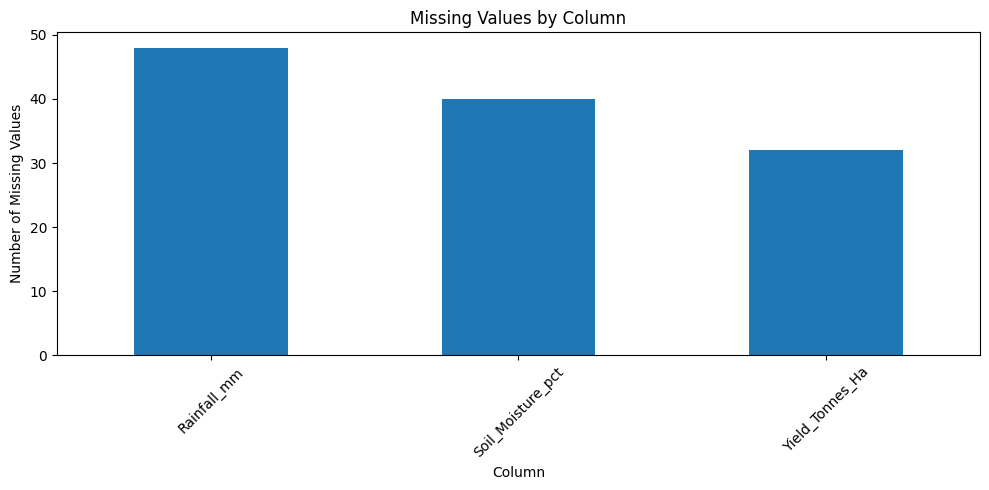

In [16]:
plt.figure(figsize=(10, 5))

missing[missing > 0].sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
print(df.isnull().sum().sum())

Missing values after treatment:
0


In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

Number of duplicate records: 0
No duplicate records found.


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [20]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n" + "="*50)
    print(col)
    print("="*50)
    print(df[col].value_counts())


Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count,

In [21]:


numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Column": col,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    "Outlier_Count",
    ascending=False
)

,Column,Outlier_Count,Outlier_Percentage
18,Profit_INR,404,10.100
14,Production_Tonnes,333,8.325
20,Water_Efficiency_t_per_1000m3,322,8.050
13,Yield_Tonnes_Ha,302,7.550
19,Water_Used_m3,276,6.900
17,Revenue_INR,240,6.000
9,Potassium_kg_ha,32,0.800
4,Sunlight_Hours_Day,26,0.650
8,Phosphorus_kg_ha,16,0.400
10,Fertilizer_kg_ha,15,0.375


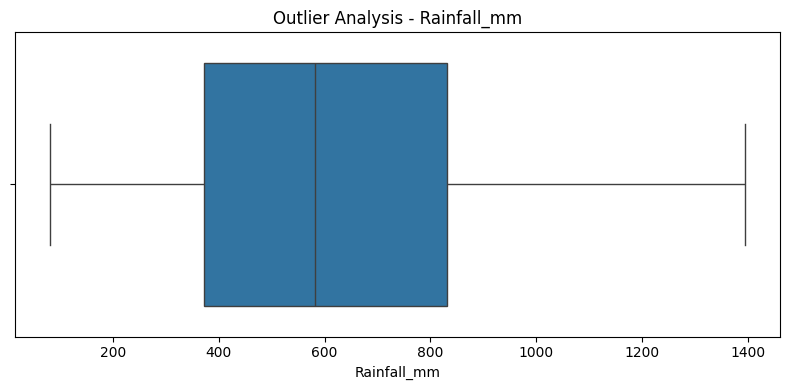

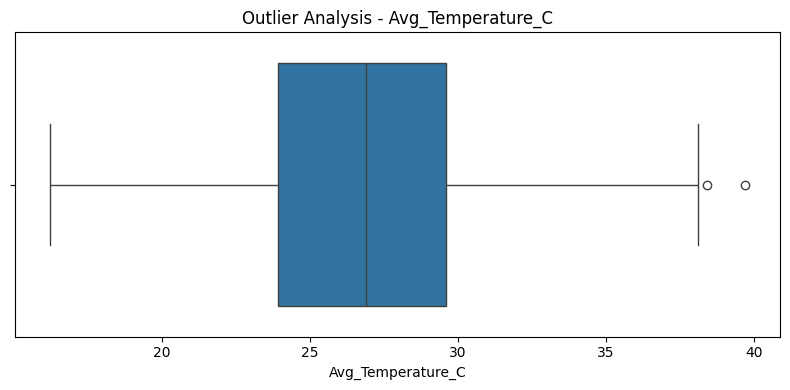

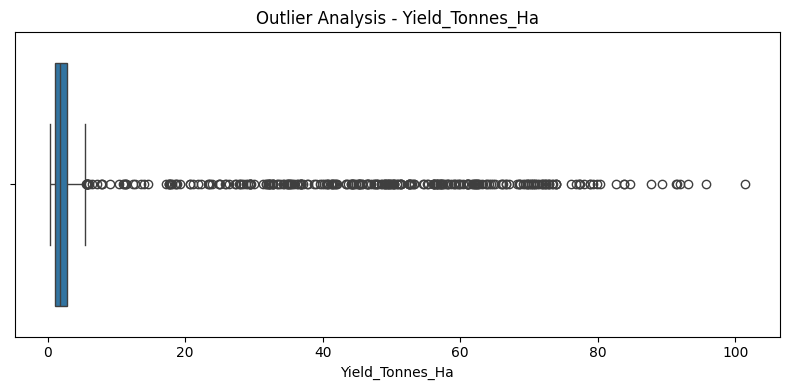

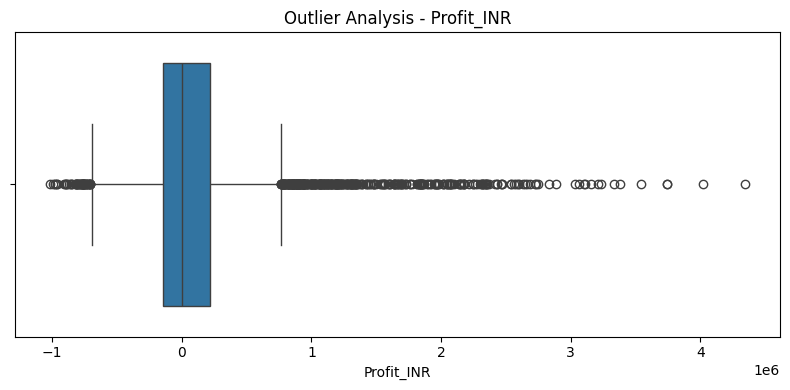

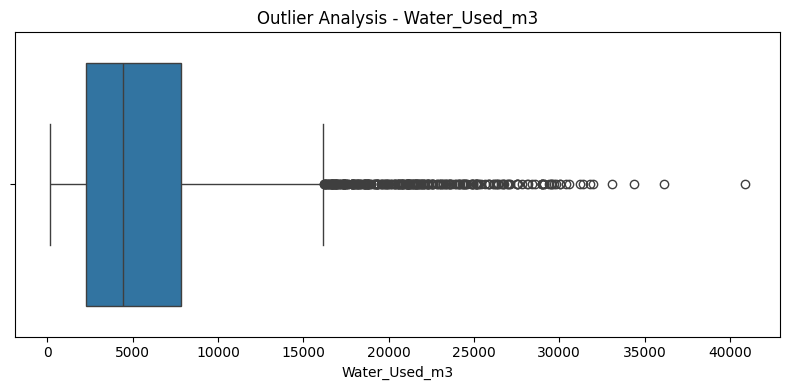

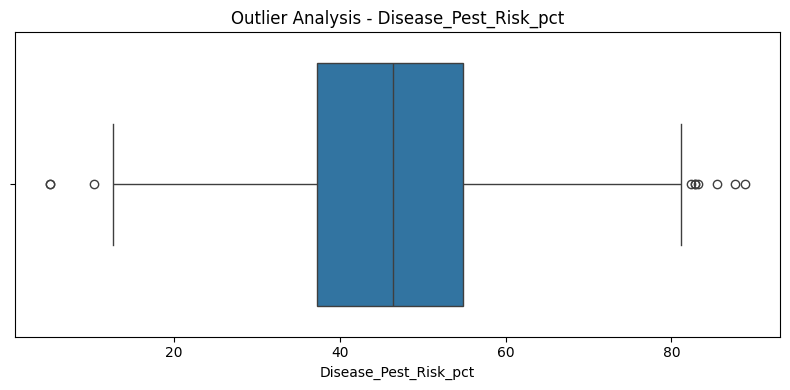

In [22]:


important_numeric = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

for col in important_numeric:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Outlier Analysis - {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

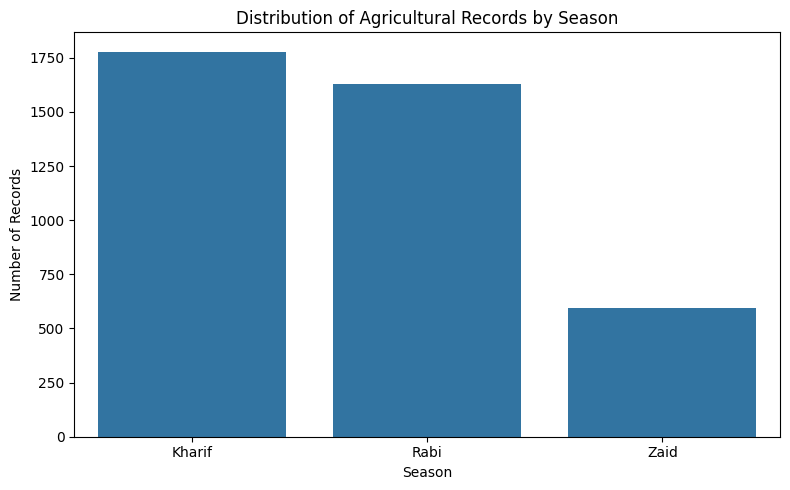

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season"
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

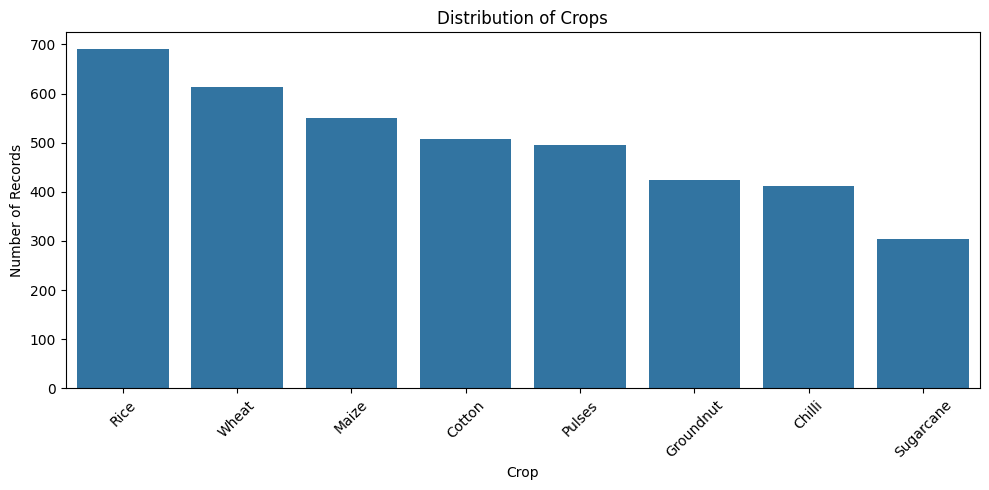

In [24]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

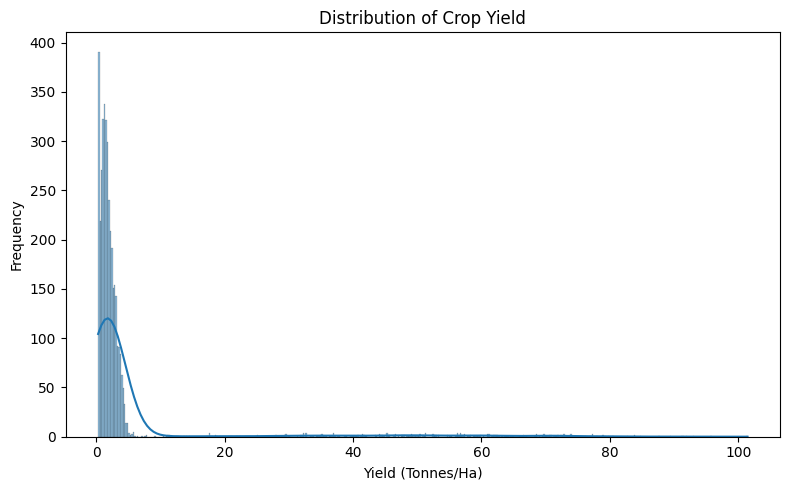

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Yield_Tonnes_Ha",
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

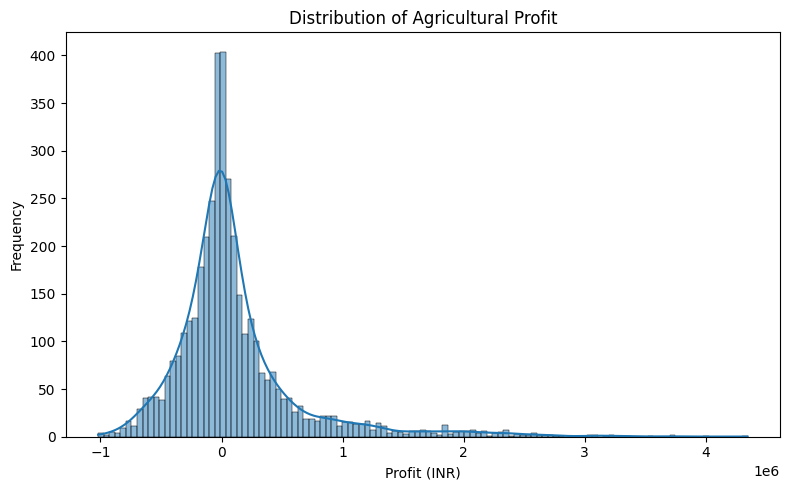

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Profit_INR",
    kde=True
)

plt.title("Distribution of Agricultural Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

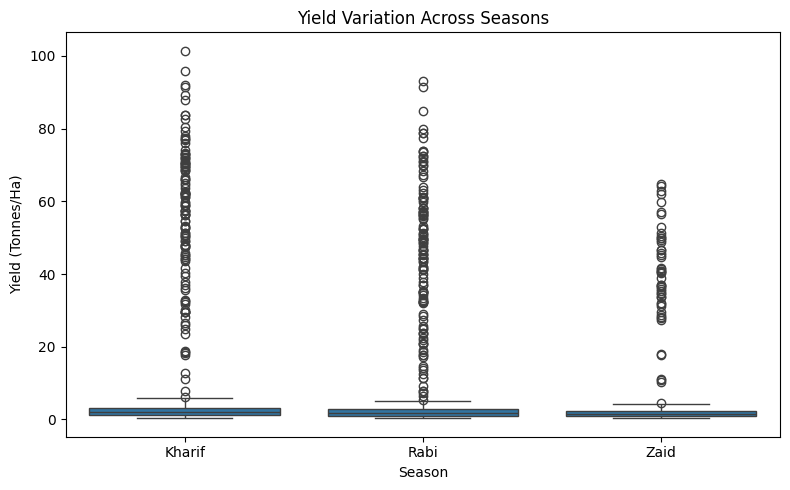

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

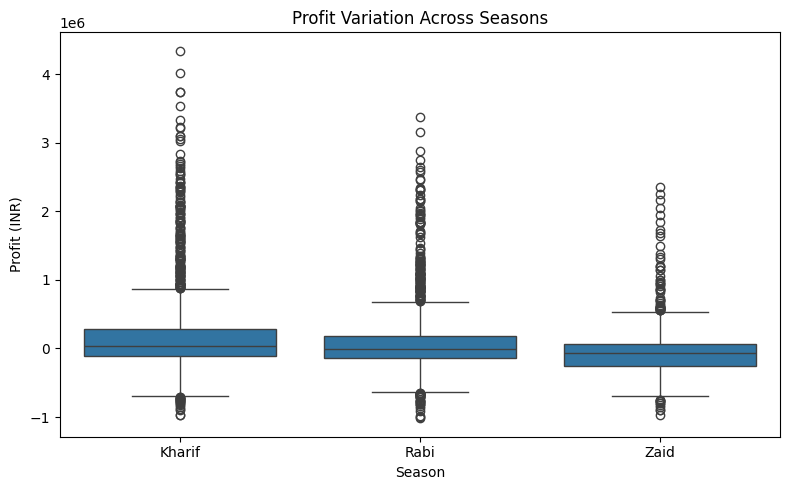

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

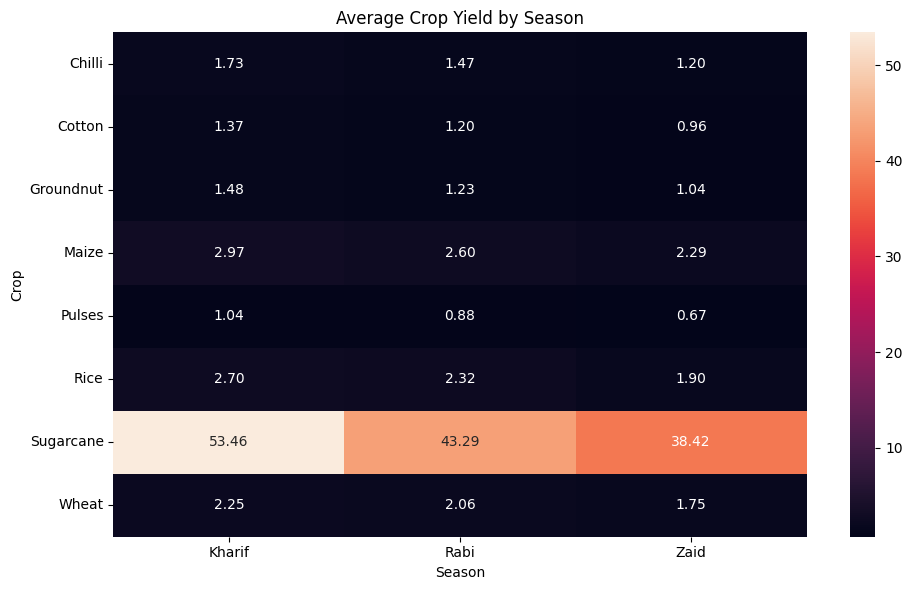

In [29]:
season_crop = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

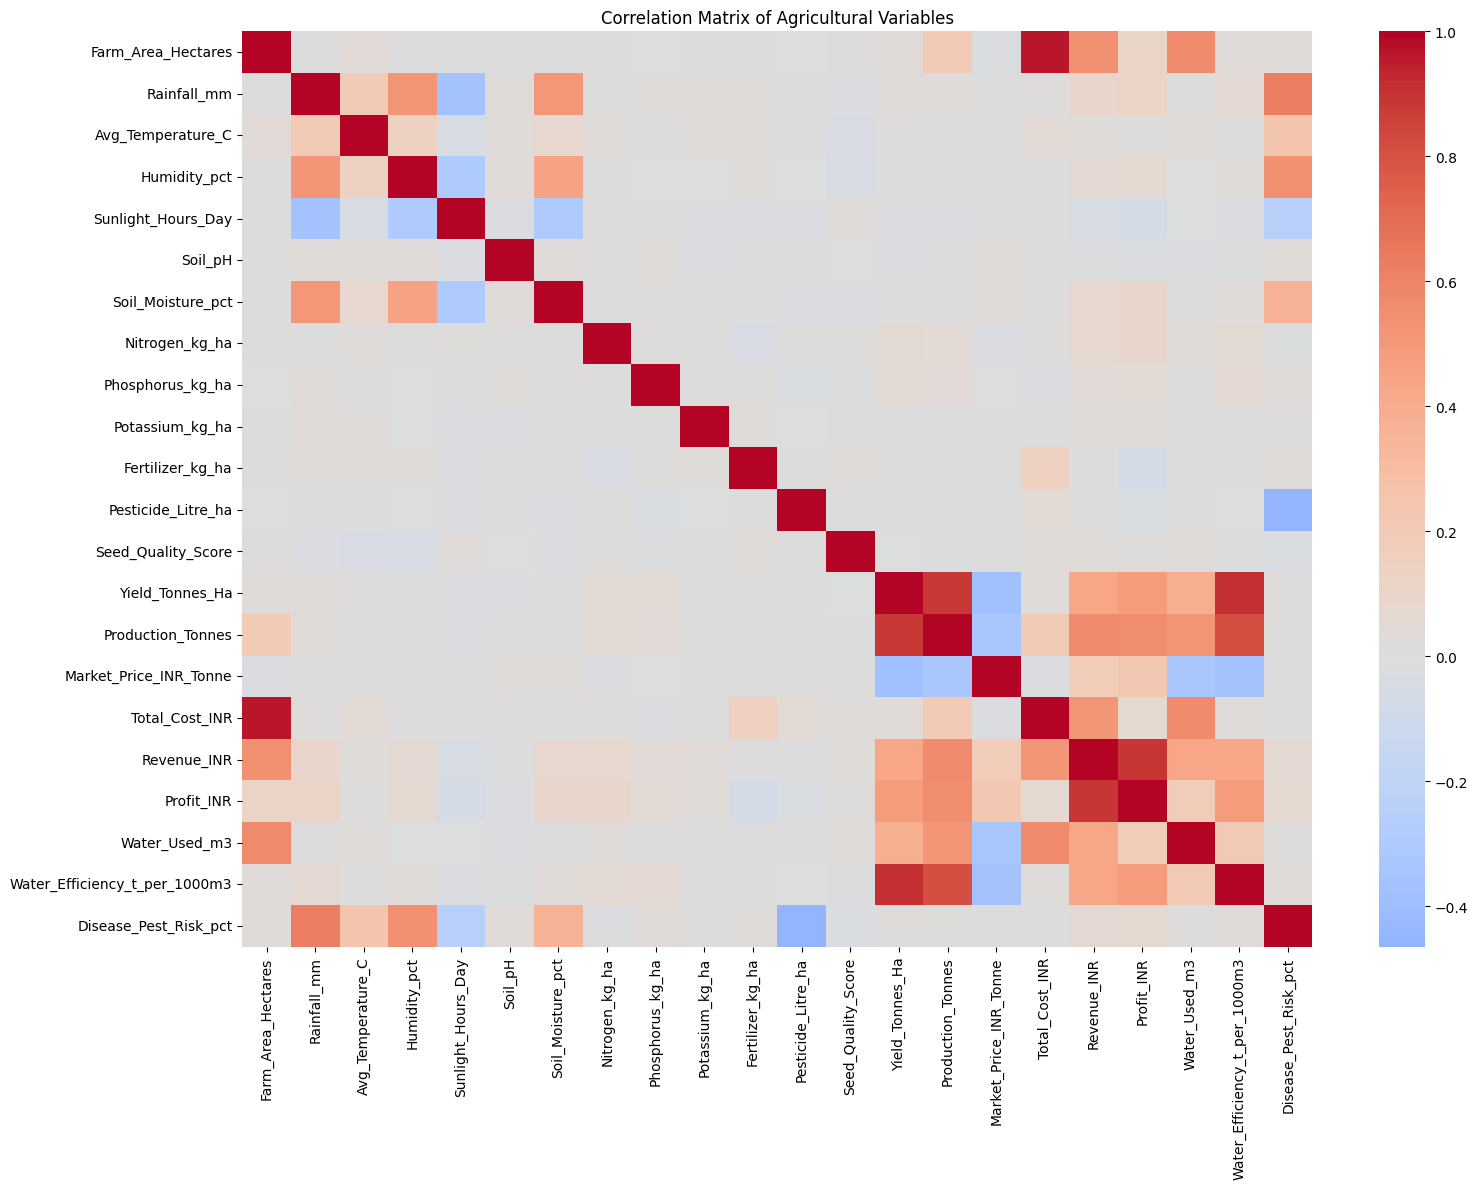

In [30]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

In [31]:
yield_corr = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_corr

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [32]:

profit_corr = (
    correlation_matrix["Profit_INR"]
    .sort_values(ascending=False)
)

profit_corr

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


In [33]:
season_summary = df.groupby("Season").agg({

    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"

}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,178914.65,710719.06,531804.41,6102.20,5.89,54.47
Rabi,5.04,41.49,87689.47,601526.05,513836.58,5846.99,5.19,40.48
Zaid,4.64,38.89,-24804.82,519171.90,543976.73,6419.89,4.41,38.22


In [34]:
environmental_summary = df.groupby("Season").agg({

    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean"

}).round(2)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


In [35]:
crop_season_yield = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
)

best_crop_each_season = (
    crop_season_yield
    .loc[
        crop_season_yield.groupby("Season")["Yield_Tonnes_Ha"]
        .idxmax()
    ]
)

best_crop_each_season

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.286124
22,Zaid,Sugarcane,38.423922


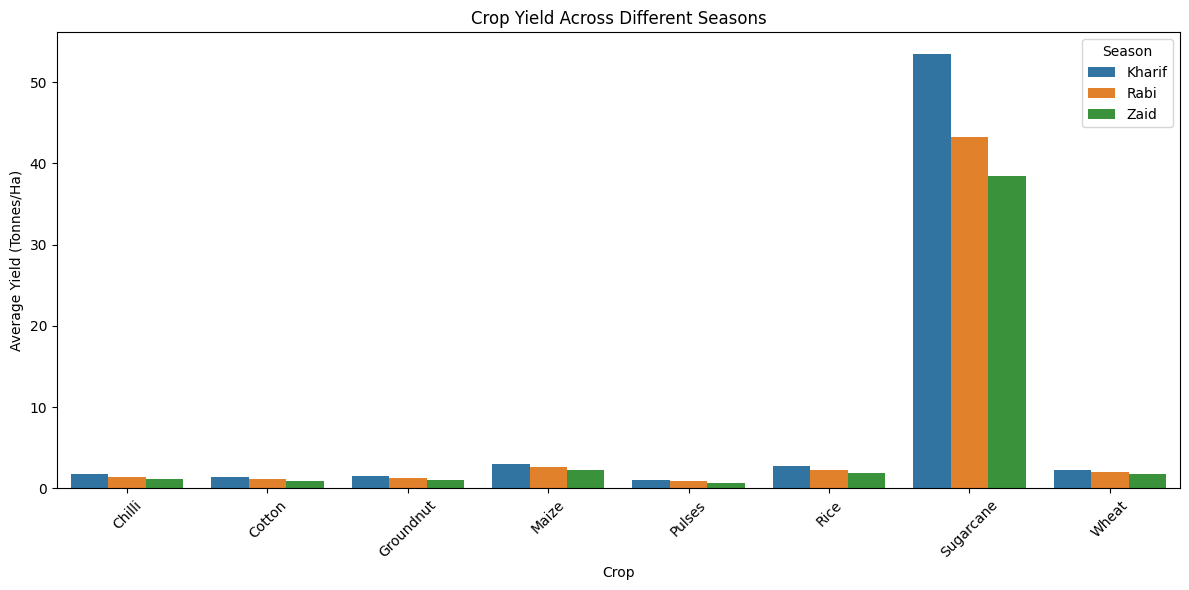

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=crop_season_yield,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Crop Yield Across Different Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
irrigation_analysis = (
    df.groupby("Irrigation_Method")
    .agg({
        "Yield_Tonnes_Ha": "mean",
        "Profit_INR": "mean",
        "Water_Used_m3": "mean",
        "Water_Efficiency_t_per_1000m3": "mean"
    })
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

irrigation_analysis

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.577989,219625.997814,5918.747541,6.267129
Sprinkler,5.160627,91121.079019,6208.258856,4.669805
Flood,4.863977,73354.022901,8026.472519,3.438853
Rainfed,4.602142,79050.365034,3549.554275,7.563784


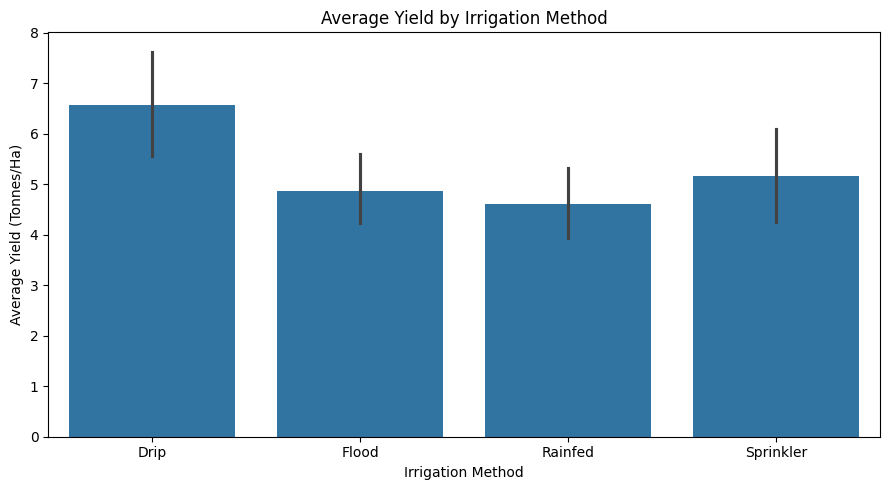

In [38]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

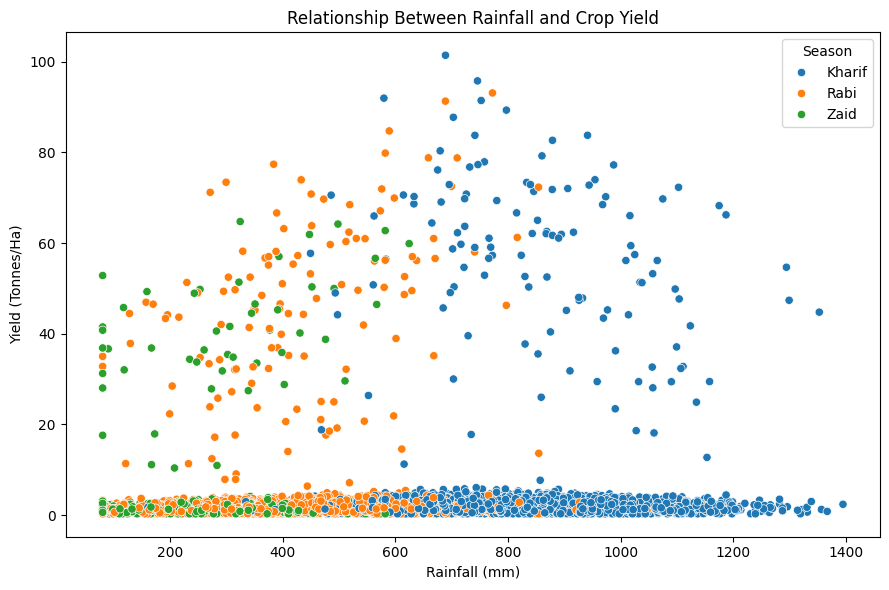

In [39]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [40]:
rainfall_yield_corr = df[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr()

rainfall_yield_corr

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030951
Yield_Tonnes_Ha,0.030951,1.000000


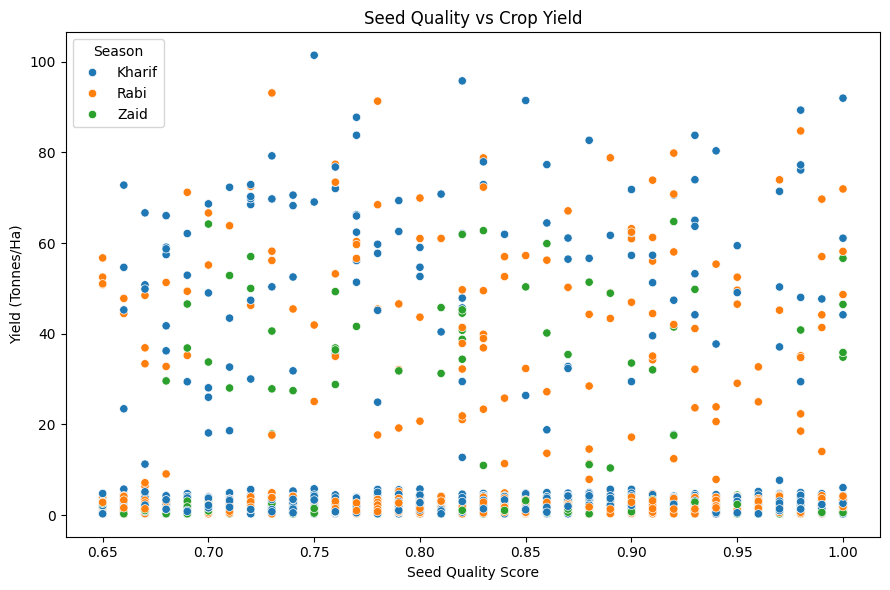

In [41]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Seed Quality vs Crop Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

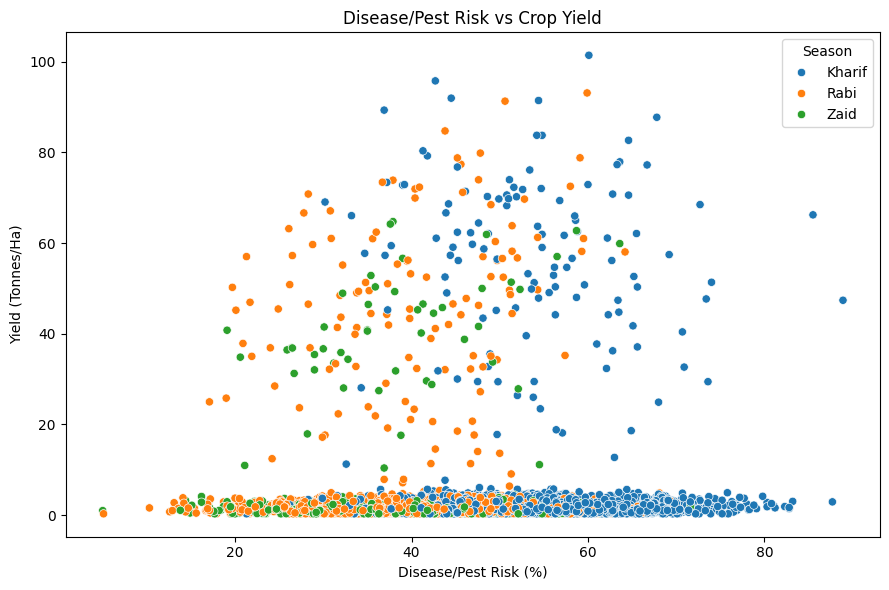

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Disease_Pest_Risk_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Disease/Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [43]:
state_analysis = (
    df.groupby("State")
    .agg({
        "Yield_Tonnes_Ha": "mean",
        "Profit_INR": "mean",
        "Production_Tonnes": "mean"
    })
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

state_analysis

,Yield_Tonnes_Ha,Profit_INR,Production_Tonnes
State,,,
Punjab,6.121116,136025.636364,52.233099
Karnataka,5.685481,119422.335378,47.732720
Gujarat,5.659016,117568.235656,48.331988
Telangana,5.044477,108829.616279,39.254186
Maharashtra,5.017480,135428.855469,43.984043
Madhya Pradesh,4.989940,86840.756539,37.559517
Tamil Nadu,4.875175,117744.748454,40.840371
Andhra Pradesh,4.628771,73453.527410,36.913157


In [44]:
top_10_farms = (
    df[
        [
            "Farm_ID",
            "State",
            "District",
            "Crop",
            "Season",
            "Profit_INR"
        ]
    ]
    .sort_values("Profit_INR", ascending=False)
    .head(10)
)

top_10_farms

,Farm_ID,State,District,Crop,Season,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,3159447


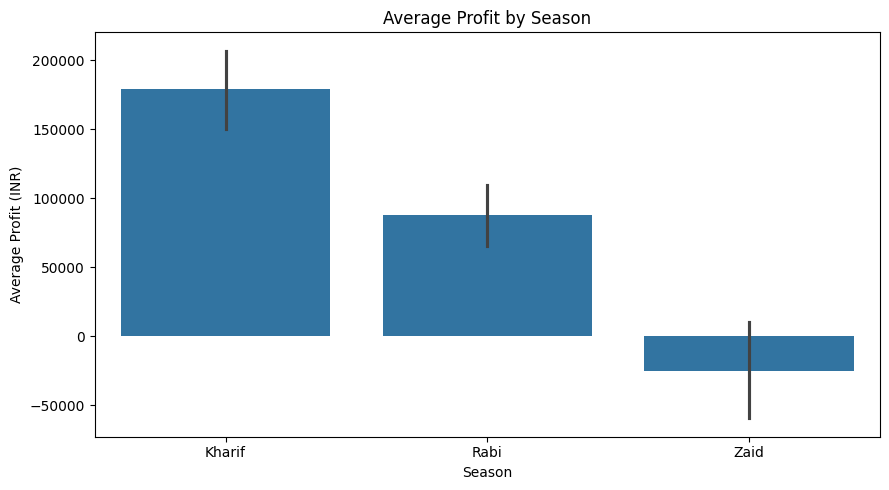

In [45]:

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean"
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

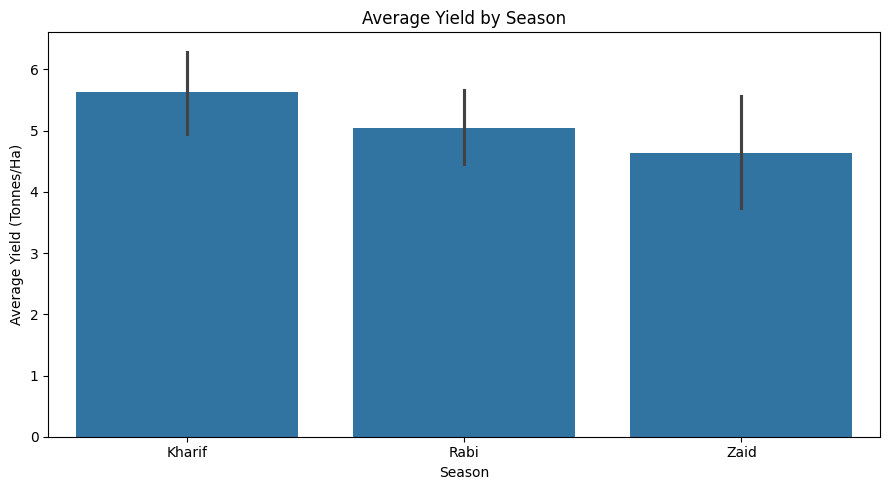

In [46]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [47]:
water_analysis = (
    df.groupby("Season")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

water_analysis

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


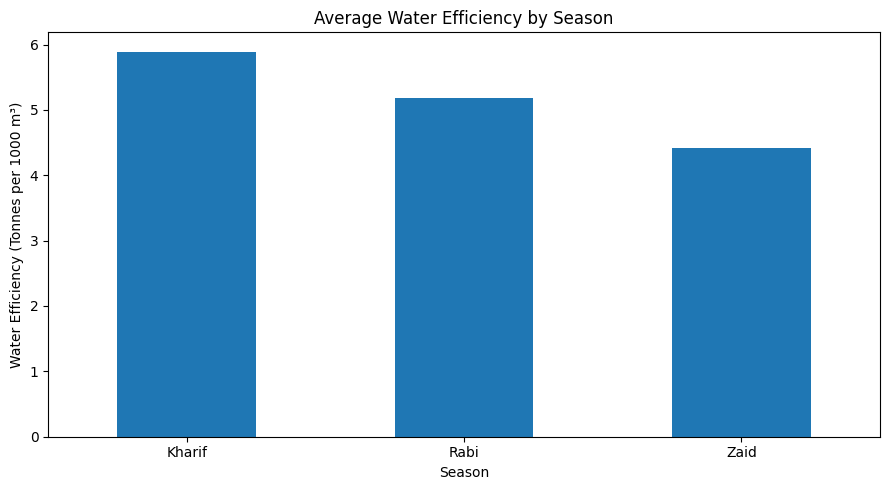

In [48]:
plt.figure(figsize=(9, 5))

water_analysis.plot(kind="bar")

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
df["Profit_Margin_Percentage"] = (
    df["Profit_INR"] / df["Revenue_INR"]
) * 100

df[
    [
        "Season",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR",
        "Profit_Margin_Percentage"
    ]
].head()

,Season,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_Percentage
0,Kharif,30810,42662,-11852,-38.468030
1,Kharif,40401,492351,-451950,-1118.660429
2,Rabi,190466,315210,-124744,-65.494104
3,Kharif,200740,296444,-95704,-47.675600
4,Zaid,193607,337959,-144352,-74.559288


In [50]:
profitability_by_season = (
    df.groupby("Season")
    .agg({
        "Revenue_INR": "mean",
        "Total_Cost_INR": "mean",
        "Profit_INR": "mean",
        "Profit_Margin_Percentage": "mean"
    })
    .round(2)
)

profitability_by_season

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_Percentage
Season,,,,
Kharif,710719.06,531804.41,178914.65,-38.64
Rabi,601526.05,513836.58,87689.47,-44.27
Zaid,519171.90,543976.73,-24804.82,-69.35


In [51]:



# 1. Best season by yield
best_yield_season = season_summary["Yield_Tonnes_Ha"].idxmax()
best_yield_value = season_summary["Yield_Tonnes_Ha"].max()

print(
    f"1. {best_yield_season} has the highest average yield "
    f"of {best_yield_value:.2f} tonnes/ha."
)

# 2. Best season by profit
best_profit_season = season_summary["Profit_INR"].idxmax()
best_profit_value = season_summary["Profit_INR"].max()

print(
    f"2. {best_profit_season} has the highest average profit "
    f"of INR {best_profit_value:,.2f}."
)

# 3. Highest production
best_production_season = season_summary["Production_Tonnes"].idxmax()

print(
    f"3. {best_production_season} has the highest average production."
)

# 4. Best water efficiency
best_water_season = season_summary[
    "Water_Efficiency_t_per_1000m3"
].idxmax()

print(
    f"4. {best_water_season} has the highest average water efficiency."
)

# 5. Lowest disease/pest risk
lowest_risk_season = season_summary[
    "Disease_Pest_Risk_pct"
].idxmin()

print(
    f"5. {lowest_risk_season} has the lowest average disease/pest risk."
)

# 6. Highest rainfall
highest_rainfall_season = environmental_summary[
    "Rainfall_mm"
].idxmax()

print(
    f"6. {highest_rainfall_season} has the highest average rainfall."
)

# 7. Highest temperature
highest_temp_season = environmental_summary[
    "Avg_Temperature_C"
].idxmax()

print(
    f"7. {highest_temp_season} has the highest average temperature."
)

# 8. Best irrigation method by yield
best_irrigation = irrigation_analysis[
    "Yield_Tonnes_Ha"
].idxmax()

print(
    f"8. {best_irrigation} irrigation has the highest average yield "
    f"among the irrigation methods."
)

1. Kharif has the highest average yield of 5.63 tonnes/ha.
2. Kharif has the highest average profit of INR 178,914.65.
3. Kharif has the highest average production.
4. Kharif has the highest average water efficiency.
5. Zaid has the lowest average disease/pest risk.
6. Kharif has the highest average rainfall.
7. Zaid has the highest average temperature.
8. Drip irrigation has the highest average yield among the irrigation methods.
